# Golf Swing Sound Classification - TinyML Pipeline (offline companion)

This notebook is the code companion to our Edge Impulse project. In Edge Impulse we built three impulses:

- **Baseline (#1)** - 500 ms window, the original model (74.5% test)
- **Compressed (#2)** - 250 ms window, a lighter / faster variant (54.8% test, smallest footprint)
- **Final (#3)** - 500 ms, higher-capacity model we deployed (79.4% test, AUC 0.93)

Here we reproduce the core methodology in code: load the swing recordings, augment, extract MFE-style
mel features, train a small 1D CNN, quantize it to int8 TFLite (what actually runs on the Nano 33
BLE Sense), and evaluate. Same methodology as Edge Impulse: 80/20 split with the augmented clips in
the training set only, so the test numbers stay honest.

Note: exact percentages differ from Edge Impulse (librosa MFE vs EI's MFE block, and a small test set),
but the pipeline and the key finding (Top is the hardest class) match.

## 1. Setup

In [1]:
import os, glob
import numpy as np
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

# point this at the folder with the original wav files
DATA_DIR = "Golf dataset"

SR = 16000        # the board mic runs at 16k
WIN = 8000        # 500 ms window
N_MELS = 40
N_FFT = 256
HOP = 160         # 10 ms
FRAMES = 50       # mel frames per window after padding
LABELS = ["Good", "Ground", "Top"]

np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1781301199.579793     547 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1781301223.622460     547 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Load the data

Labels come from the filename prefix (good / grnd / top). We downmix to mono and resample to 16 kHz
to match the board. We skip any augmented files (`_aug`, `_soft`) here since we make our own below.

In [2]:
def label_of(name):
    if name.startswith("grnd"): return "Ground"
    if name.startswith("good"): return "Good"
    return "Top"

def load_wav(path):
    x, sr = sf.read(path)
    if x.ndim > 1:
        x = x.mean(axis=1)
    if sr != SR:
        x = librosa.resample(x.astype(float), orig_sr=sr, target_sr=SR)
    return x.astype(np.float32)

files = [f for f in sorted(glob.glob(os.path.join(DATA_DIR, "*.wav")))
         if "_aug" not in f and "_soft" not in f]
paths = np.array(files)
y = np.array([LABELS.index(label_of(os.path.basename(f))) for f in files])

print("total recordings:", len(files))
for i, lab in enumerate(LABELS):
    print(lab, int((y == i).sum()))

total recordings: 76
Good 28
Ground 24
Top 24


## 3. Quick look at the data
Clip lengths are short and uneven, and the three classes have pretty different spectra.

duration sec: min 0.16  max 1.25  mean 0.46


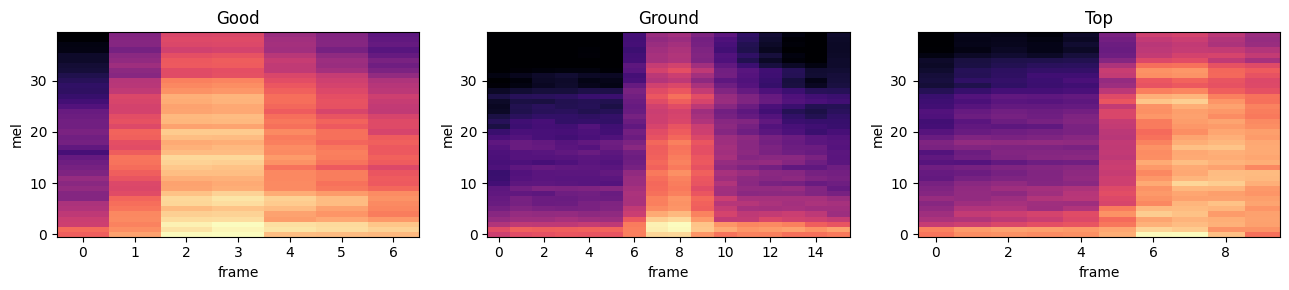

In [3]:
durs = [len(load_wav(f))/SR for f in files]
print("duration sec: min %.2f  max %.2f  mean %.2f" % (min(durs), max(durs), np.mean(durs)))

# one spectrogram per class
fig, ax = plt.subplots(1, 3, figsize=(13, 3))
for a, lab in zip(ax, LABELS):
    f = next(p for p in files if label_of(os.path.basename(p)) == lab)
    x = load_wav(f)
    S = librosa.power_to_db(librosa.feature.melspectrogram(y=x, sr=SR, n_mels=N_MELS), ref=np.max)
    a.imshow(S, origin="lower", aspect="auto", cmap="magma")
    a.set_title(lab); a.set_xlabel("frame"); a.set_ylabel("mel")
plt.tight_layout(); plt.show()

## 4. Train / test split

Split by file, stratified per class, before any augmentation. This way no augmented copy of a
training clip can leak into the test set.

In [4]:
rng = np.random.default_rng(42)
train_idx, test_idx = [], []
for c in range(3):
    idx = np.where(y == c)[0]
    rng.shuffle(idx)
    k = max(1, int(round(0.2 * len(idx))))
    test_idx += list(idx[:k])
    train_idx += list(idx[k:])
train_idx = np.array(train_idx)
test_idx = np.array(test_idx)
print("train files:", len(train_idx), " test files:", len(test_idx))

train files: 60  test files: 16


## 5. Augmentation (training only)

Gentle stuff that keeps the impact intact: small time shift, a little noise, a small gain change.
No time-stretch or pitch shift, those wreck the short top-shot transients.

In [5]:
def augment(x, rng):
    # small time shift, pad instead of wrap so the impact stays put
    shift = rng.integers(-int(0.03*SR), int(0.03*SR)+1)
    if shift > 0:
        x = np.concatenate([np.zeros(shift, np.float32), x[:-shift]])
    elif shift < 0:
        x = np.concatenate([x[-shift:], np.zeros(-shift, np.float32)])
    # light noise
    rms = np.sqrt(np.mean(x**2)) + 1e-9
    snr = rng.uniform(30, 40)
    x = x + rng.normal(0, rms/(10**(snr/20)), size=x.shape).astype(np.float32)
    # small gain jitter, then keep it from clipping
    x = x * 10**(rng.uniform(-1.5, 1.5)/20)
    m = np.max(np.abs(x))
    if m > 0.95:
        x = x * (0.95/m)
    return x

## 6. MFE features
Mel filterbank energies in dB, padded/truncated to a fixed 500 ms window. Close to what Edge Impulse's MFE block does.

In [6]:
def fix_len(x, n=WIN):
    return x[:n] if len(x) >= n else np.pad(x, (0, n - len(x)))

def mfe(x):
    x = fix_len(x)
    S = librosa.feature.melspectrogram(y=x, sr=SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS, power=2.0)
    S = librosa.power_to_db(S, ref=np.max).T   # time x mels
    if S.shape[0] >= FRAMES:
        S = S[:FRAMES]
    else:
        S = np.pad(S, ((0, FRAMES - S.shape[0]), (0, 0)))
    return S.astype(np.float32)

# build training set: original + 2 augmented copies each
Xtr, ytr = [], []
arng = np.random.default_rng(7)
for i in train_idx:
    raw = load_wav(paths[i])
    Xtr.append(mfe(raw)); ytr.append(y[i])
    for _ in range(2):
        Xtr.append(mfe(augment(raw.copy(), arng))); ytr.append(y[i])
Xtr = np.array(Xtr); ytr = np.array(ytr)

# test set: original clips only
Xte = np.array([mfe(load_wav(paths[i])) for i in test_idx])
yte = y[test_idx]

print("train windows:", Xtr.shape, " test windows:", Xte.shape)

# standardize using training stats
mean, std = Xtr.mean(), Xtr.std() + 1e-6
Xtr = (Xtr - mean)/std
Xte = (Xte - mean)/std

train windows: (180, 50, 40)  test windows: (16, 50, 40)


## 7. Model
Small 1D CNN over the mel frames, same shape as the Edge Impulse classifier (two conv blocks, dropout, dense out).

In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Input((FRAMES, N_MELS)),
    tf.keras.layers.Conv1D(8, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv1D(16, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(3, activation="softmax"),
])
model.compile(optimizer=tf.keras.optimizers.Adam(0.005),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 50, 8)          │           968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 25, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 25, 16)         │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 12, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           579 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,947 (7.61 KB)

 Trainable params: 1,947 (7.61 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Train

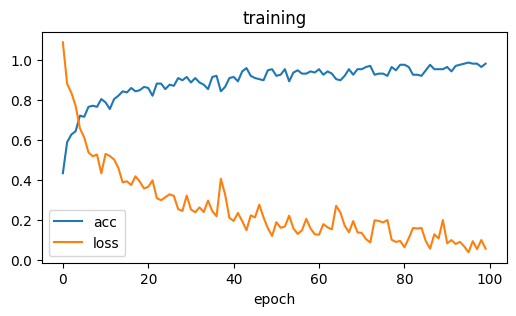

In [8]:
hist = model.fit(Xtr, ytr, epochs=100, batch_size=16, verbose=0)

plt.figure(figsize=(6, 3))
plt.plot(hist.history["accuracy"], label="acc")
plt.plot(hist.history["loss"], label="loss")
plt.xlabel("epoch"); plt.legend(); plt.title("training"); plt.show()

## 9. Evaluate the float model

float32 accuracy: 0.688
              precision    recall  f1-score   support

        Good       0.83      0.83      0.83         6
      Ground       0.57      0.80      0.67         5
         Top       0.67      0.40      0.50         5

    accuracy                           0.69        16
   macro avg       0.69      0.68      0.67        16
weighted avg       0.70      0.69      0.68        16



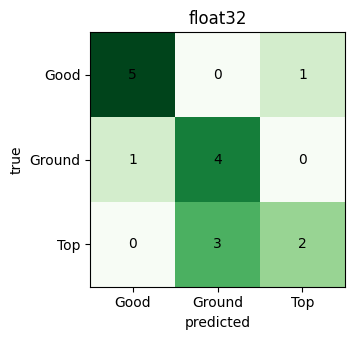

In [9]:
def show_results(true, pred, title):
    acc = (pred == true).mean()
    print(title, "accuracy: %.3f" % acc)
    print(classification_report(true, pred, target_names=LABELS, zero_division=0))
    cm = confusion_matrix(true, pred)
    plt.figure(figsize=(4, 3.5))
    plt.imshow(cm, cmap="Greens")
    plt.xticks(range(3), LABELS); plt.yticks(range(3), LABELS)
    plt.xlabel("predicted"); plt.ylabel("true"); plt.title(title)
    for i in range(3):
        for j in range(3):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout(); plt.show()

pred = model.predict(Xte, verbose=0).argmax(1)
show_results(yte, pred, "float32")

## 10. Quantize to int8 TFLite

This is the version that actually runs on the board. We pass a representative dataset so the
converter can pick good int8 scales.

In [10]:
def rep_data():
    for i in range(min(100, len(Xtr))):
        yield [Xtr[i:i+1].astype(np.float32)]

conv = tf.lite.TFLiteConverter.from_keras_model(model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.representative_dataset = rep_data
conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv.inference_input_type = tf.int8
conv.inference_output_type = tf.int8
tflite_model = conv.convert()

with open("golf_model_int8.tflite", "wb") as fp:
    fp.write(tflite_model)
print("int8 model size: %.1f KB" % (len(tflite_model)/1024))

INFO:tensorflow:Assets written to: /tmp/tmp46u01ss3/assets


INFO:tensorflow:Assets written to: /tmp/tmp46u01ss3/assets


Saved artifact at '/tmp/tmp46u01ss3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 40), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139718551985936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139718551986704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139718551986320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139718551987280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139718551987472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139718551988624: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


int8 model size: 9.5 KB


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## 11. Evaluate the int8 model

int8 (on-device) accuracy: 0.688
              precision    recall  f1-score   support

        Good       0.83      0.83      0.83         6
      Ground       0.57      0.80      0.67         5
         Top       0.67      0.40      0.50         5

    accuracy                           0.69        16
   macro avg       0.69      0.68      0.67        16
weighted avg       0.70      0.69      0.68        16



/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


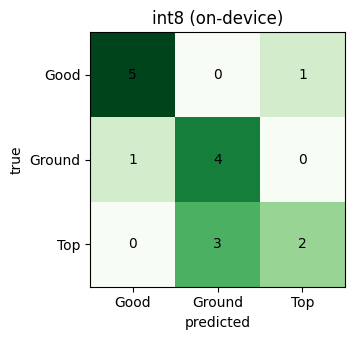

In [11]:
interp = tf.lite.Interpreter(model_content=tflite_model)
interp.allocate_tensors()
inp = interp.get_input_details()[0]
out = interp.get_output_details()[0]
scale, zp = inp["quantization"]

qpred = []
for i in range(len(Xte)):
    q = np.round(Xte[i:i+1]/scale + zp).astype(np.int8)
    interp.set_tensor(inp["index"], q)
    interp.invoke()
    qpred.append(interp.get_tensor(out["index"])[0].argmax())
qpred = np.array(qpred)

show_results(yte, qpred, "int8 (on-device)")

## 12. Single-clip inference

This is what the board does per window: take one recording, make features, run the int8 model, and
print the predicted class with its confidence.

In [12]:
def predict_wav(path):
    x = mfe(load_wav(path))
    x = ((x - mean)/std).astype(np.float32)[None]
    q = np.round(x/scale + zp).astype(np.int8)
    interp.set_tensor(inp["index"], q)
    interp.invoke()
    o = interp.get_tensor(out["index"])[0].astype(np.float32)
    oscale, ozp = out["quantization"]
    probs = (o - ozp) * oscale            # dequantize to scores
    probs = np.exp(probs)/np.exp(probs).sum()
    k = int(probs.argmax())
    return LABELS[k], float(probs[k])

# try it on one test clip
f = paths[test_idx[0]]
label, conf = predict_wav(f)
print("file :", os.path.basename(f))
print("true :", LABELS[y[test_idx[0]]])
print("pred :", label, "(%.0f%% confidence)" % (conf*100))

file : good15.wav
true : Good
pred : Good (53% confidence)


## 13. Takeaways

- Same story as the Edge Impulse build: Good and Ground separate well, Top overlaps with Good and is
  the hard class. That overlap is acoustic, not a bug.
- int8 quantization barely changes accuracy but shrinks the model to a few KB, small enough for the
  Nano 33 BLE Sense.
- The held-out test set is real clips only (augmentation stayed in training), so these numbers are honest.

In Edge Impulse the final deployed model (Impulse #3) reaches 79.4% test accuracy and 0.93 AUC. This
offline notebook reproduces the methodology rather than the exact model, so its numbers differ, but
the trends and the Top-is-hardest conclusion line up.